# Stage 4 — Cluster Analysis (Human-in-the-Loop)

**Input**: `adata.h5ad`, dot plot, heatmap, `top_markers.csv` from Stage 3  
**Output**: `cluster_labels.csv` (cluster_id, label, group)  
**Scope**: Per machine — interactive labelling and grouping of clusters.

Review the Stage 3 visualisations, then use the widget below to assign a **cell-type label** and **group** to each cluster.

In [5]:
import pandas as pd
from IPython.display import display, Image as IPImage, SVG
from pathlib import Path

from pipeline.config import load_config
from pipeline.io import load_adata, save_cluster_labels, validate_stage_inputs
from pipeline.widgets import create_cluster_label_widget

cfg = load_config("config.yaml")

In [6]:
# ── Select machine ──
MACHINE = list(cfg.machines.keys())[0]
print(f"Available machines: {list(cfg.machines.keys())}")
print(f"Selected: {MACHINE}")

stage3_dir = cfg.stage_dir(3, MACHINE)
stage4_dir = cfg.ensure_stage_dir(4, MACHINE)

# Validate Stage 3 outputs exist
validate_stage_inputs(
    [stage3_dir / "adata.h5ad", stage3_dir / "top_markers.csv"],
    "Stage 4",
)

Available machines: ['machine_A']
Selected: machine_A
[Stage 4] All required inputs found ✓


## Review Stage 3 Results

Examine the dot plot, heatmap, and top markers to inform your cluster labelling.

Clusters found: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '3', '4', '5', '6', '7', '8', '9']

Top markers per cluster:


/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,CD11b REA1321,-8.838554,9.268686,9.696512e-19,1.101876e-18
1,0,Ki 67 REAL1047,22.292393,3.587761,4.379490e-110,6.842953e-110
2,0,CD73 REAL1172,-30.256397,2.392553,4.298349e-201,7.163915e-201
3,0,HLA DR REAL550,13.965131,1.361694,2.544375e-44,3.180469e-44
4,0,Podoplanin REA446,2.181643,0.708503,2.913590e-02,3.034990e-02
...,...,...,...,...,...,...
140,28,CD163 REA1309,5.990355,17.944944,2.093837e-09,5.234594e-08
141,28,CD235a REA175,2.696776,6.027806,7.001443e-03,4.256467e-02
142,28,CD11b REA1321,-1.968221,4.780737,4.904256e-02,1.532580e-01
143,28,Arginase 1 REAL1137,0.222839,3.466484,8.236609e-01,8.952836e-01



--- dotplot.svg ---


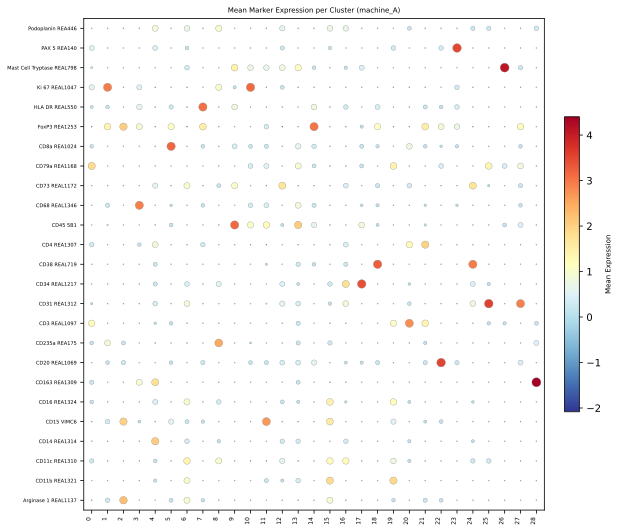


--- heatmap.svg ---


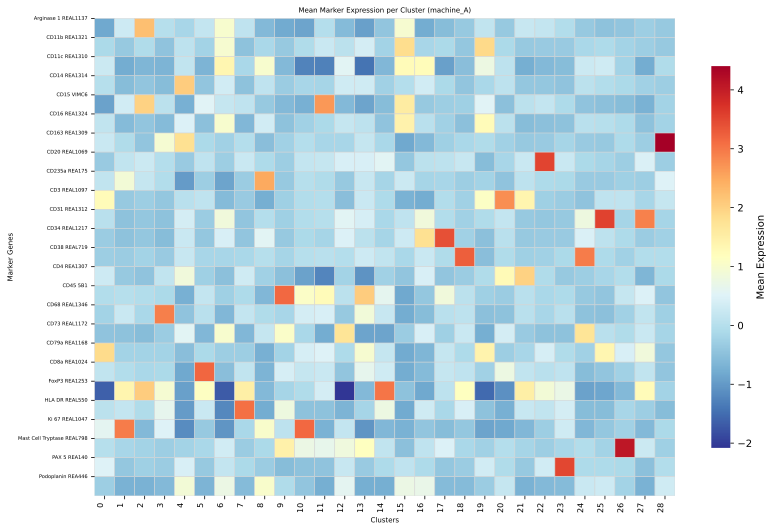

In [7]:
# Load Stage 3 outputs
adata = load_adata(stage3_dir / "adata.h5ad")
top_markers = pd.read_csv(stage3_dir / "top_markers.csv")

print(f"Clusters found: {sorted(adata.obs['leiden'].unique().tolist())}")
print(f"\nTop markers per cluster:")
display(top_markers)

# Display saved plots
for plot_name in ["dotplot.svg", "heatmap.svg"]:
    plot_path = stage3_dir / plot_name
    if plot_path.exists():
        print(f"\n--- {plot_name} ---")
        display(SVG(filename=str(plot_path)))

## Assign Cluster Labels & Groups

For each cluster:
- **Label**: The cell-type name (e.g., "CD8 T Cell", "Macrophage")
- **Group**: A category for pooling (e.g., "T Cells", "Myeloid"). Clusters sharing the same group will be merged in Stage 5.

If you leave Group empty, it defaults to the Label.

In [9]:
cluster_ids = sorted(adata.obs["leiden"].unique().tolist(), key=lambda x: int(x) if x.isdigit() else x)

# Save callback
def save_labels(df):
    save_cluster_labels(df, stage4_dir / "cluster_labels.csv")

widget = create_cluster_label_widget(cluster_ids, save_callback=save_labels)
display(widget)

## Verify Saved Labels

Run this cell after clicking "Save Labels" above to confirm the output.

In [10]:
from pipeline.io import load_cluster_labels

labels_path = stage4_dir / "cluster_labels.csv"
if labels_path.exists():
    saved = load_cluster_labels(labels_path)
    display(saved)
    print(f"\n✓ Stage 4 complete for machine '{MACHINE}'")
    print(f"  Output: {labels_path}")
else:
    print("⚠ No labels saved yet. Use the widget above to assign labels, then click Save.")

,cluster_id,label,group
0,0,Unspecific,Unspecific
1,1,Unspecific,Unspecific
2,2,Unspecific,Unspecific
3,3,Unspecific,Unspecific
4,4,Unspecific,Unspecific
5,5,Unspecific,Unspecific
6,6,Unspecific,Unspecific
7,7,Unspecific,Unspecific
8,8,Unspecific,Unspecific
9,9,Unspecific,Unspecific



✓ Stage 4 complete for machine 'machine_A'
  Output: experiments/my_experiment/stage4_analysis/machine_A/cluster_labels.csv
